**Часть 1. EDA**

**Данные с Kaggle по ценам на жильё в Airbnb в Нью-Йорке заранее скачаны в локальную директорию ./homework_10/data/AB_NYC_2019.csv**

1.1 Основные шаги работы с данными


In [42]:
#Импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [19]:
#Читаем файл с данными, смотрим размерность и структуру данных
data = pd.read_csv('data/AB_NYC_2019.csv')
print('Размерность датасета:', data.shape)
data.head()

Размерность датасета: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [20]:
#Удаляем ненужные признаки
data = data.drop(columns=['id', 'name', 'host_id', 'host_name', 'last_review'])
print('Размерность после удаления признаков:', data.shape)
data.head()

Размерность после удаления признаков: (48895, 11)


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [21]:
#Анализ типов признаков
print(data.dtypes)

neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


In [23]:
#Смотрим описание признаков
#Сам датасет не собержит метаданных по описанию значений признаков. Попробуем найти (или предположить описание по значениям в столбце)
# Нашли источник https://insideairbnb.com ->  https://docs.google.com/spreadsheets/d/1iWCNJcSutYqpULSQHlNyGInUvHg2BoUGoNRIGa6Szc4/edit?gid=1343655814#gid=1343655814
# Data Dictionary for listings.csv summary file
# *Перевод на русский язык любительский без претензии на официальные значения.

# neighbourhood_group   Округ = административный район = группа районов (The neighbourhood group as geocoded using the latitude and longitude against neighborhoods as defined by open or public digital shapefiles)
# neighbourhood	        Район внутри округа (The neighbourhood as geocoded using the latitude and longitude against neighborhoods as defined by open or public digital shapefiles.)
# latitude              Широта (Uses the World Geodetic System (WGS84) projection for latitude and longitude.)
# longitude	            Долгота (Uses the World Geodetic System (WGS84) projection for latitude and longitude.)
# room_type	            Тип жилья: Entire home\apt / Private room & etc.
# price	                Цена за сутки, $ (daily price in local currency. Note, $ sign may be used despite locale)
# minimum_nights	    Минимальное количество ночей для размещения  (хозяин устанавливает сам?) (minimum number of night stay for the listing (calendar rules may be different))
# number_of_reviews	    Общее количество отзывов (The number of reviews the listing has)
# reviews_per_month     Количество отзывов в месяц (среднее? возможно, показатель популярности)
# calculated_host_listings_count	Количество объявлений, которые хозяин имеет в текущем поиске, в географическом районе города/региона (The number of listings the host has in the current scrape, in the city/region geography.)
# availability_365	Доступность объявления через Х дней в будущем, определяемая календарем (avaliability_x. The availability of the listing x days in the future as determined by the calendar. Note a listing may be available because it has been booked by a guest or blocked by the host.)


**Целевая переменная** `price` (Цена за сутки, $). Это то, что мы будем предсказывать.

In [24]:
#Базовая статистика
data.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [25]:
#Пропущенные значения
print(data.isnull().sum())

neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


видим, что с reviews_per_month многова-то пропусков... посмотрим далее.

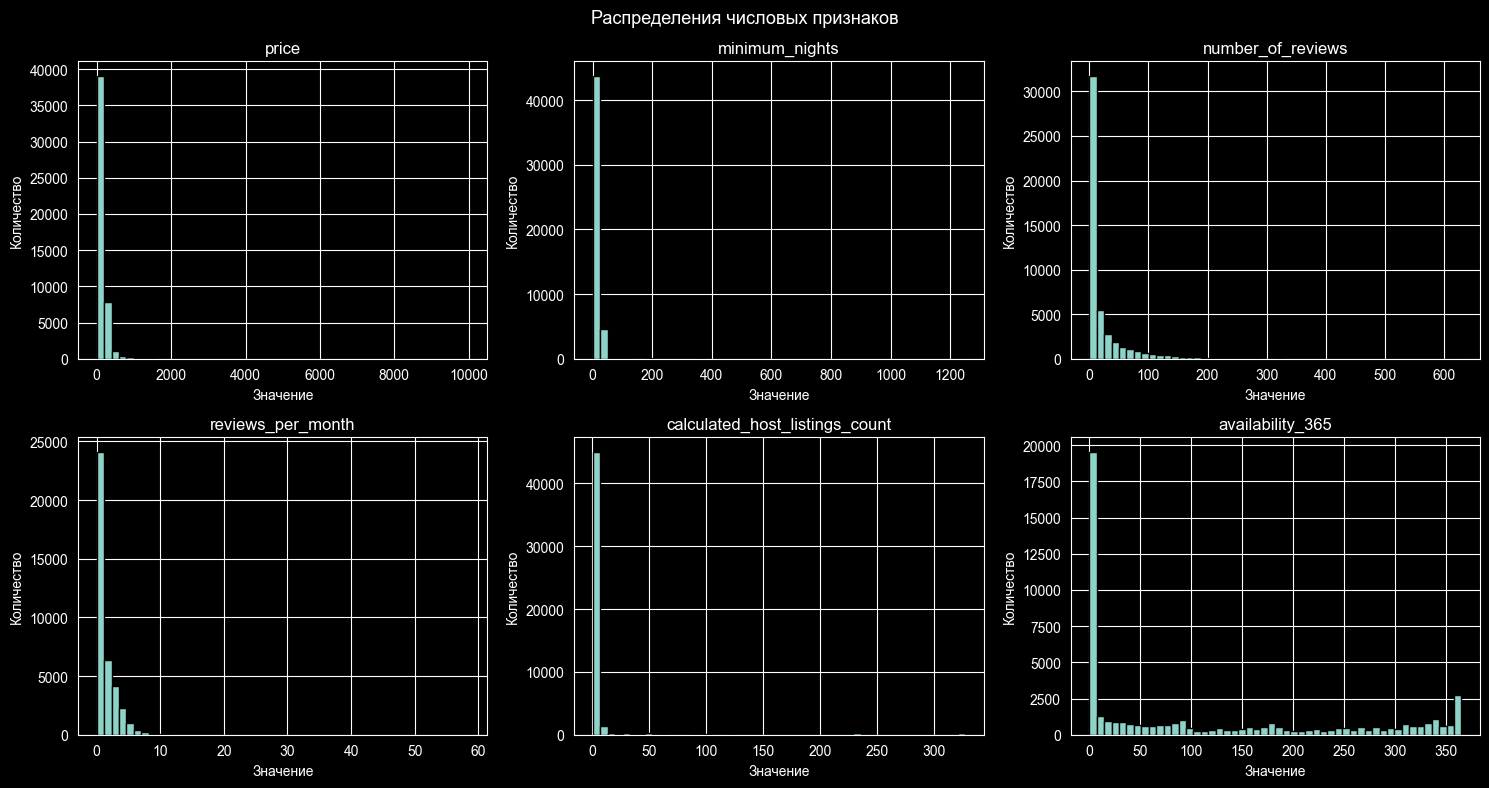

In [26]:
#Распределения числовых признаков
numeric_columns = ['price', 'minimum_nights', 'number_of_reviews',
                   'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, column_name in enumerate(numeric_columns):
    row = i // 3
    col = i % 3
    axes[row, col].hist(data[column_name].dropna(), bins=50, edgecolor='black')
    axes[row, col].set_title(column_name)
    axes[row, col].set_xlabel('Значение')
    axes[row, col].set_ylabel('Количество')

plt.suptitle('Распределения числовых признаков', fontsize=13)
plt.tight_layout()
plt.show()

**Наблюдения по распределениям:**
- `price`, `minimum_nights`, `number_of_reviews`, `reviews_per_month`, `calculated_host_listings_count` признаки скошены, большинство значений сосредоточено у небольших положительных чисел. Это указывает на необходимость логарифмирования + нормирования значений признаков.
- `availability_365` много объявлений либо почти недоступны (0 дней), либо доступны почти весь год (365 дней).


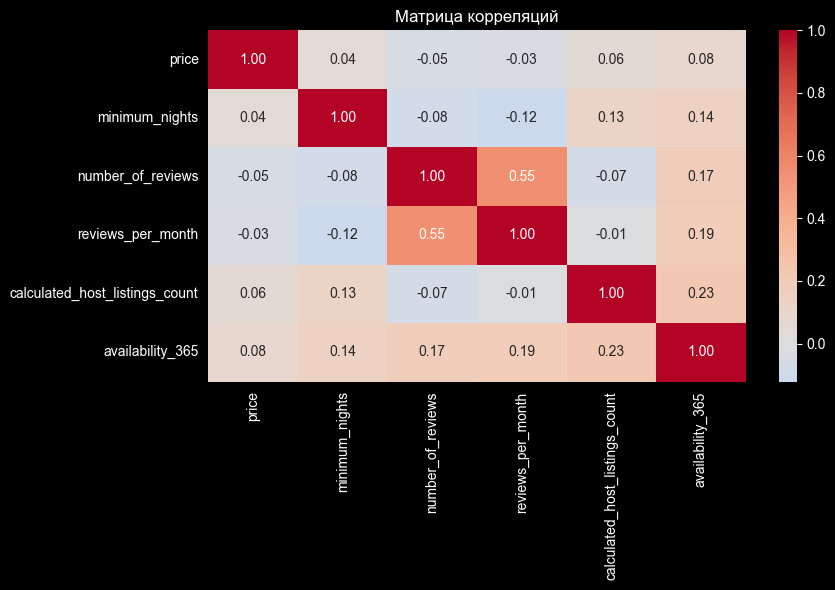

In [27]:
#Матрица попарных корреляций
correlation_matrix = data[numeric_columns].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

**Наблюдения по корреляциям:**
- `price` и [`number_of_reviews`, `reviews_per_month`, `availability_365`] слабо коррелированы. Корреляция близка к нулю, значит, признаки не несут полезной информации для модели. Можнобудет удалить, чтобы облегчить модель.


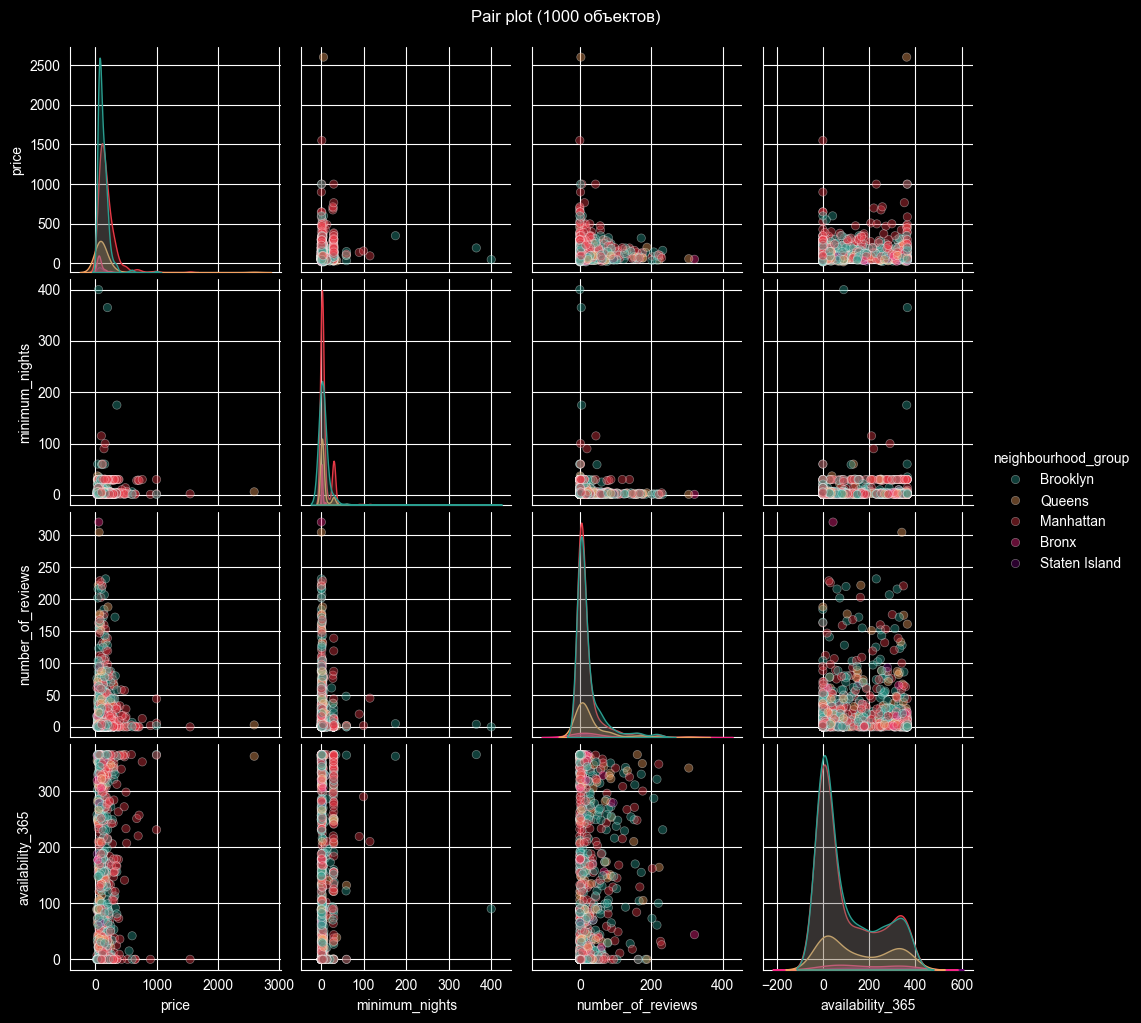

In [28]:
#Pair plot на подвыборке по округам из 1000 записей
pairplot_columns = ['price', 'minimum_nights', 'number_of_reviews', 'availability_365', 'neighbourhood_group']
data_sample = data[pairplot_columns].dropna().sample(1000, random_state=42)

neighbourhood_palette = {
    'Manhattan':    '#e63946',
    'Brooklyn':     '#2a9d8f',
    'Queens':       '#f4a261',
    'Bronx':        '#f72585',
    'Staten Island': '#6a0572'
}

sns.pairplot(data_sample, hue='neighbourhood_group', palette=neighbourhood_palette, plot_kws={'alpha': 0.4})
plt.suptitle('Pair plot (1000 объектов)', y=1.02)
plt.show()


так. Матрица корреляций показывает силу линейных связей численно. Pair plot дополняет её визуально: позволяет увидеть нелинейные зависимости, которые корреляция не улавливает, а также наглядно сравнить распределения признаков по округам. В Бруклине цена выше.

**Часть 2. Preprocessing & Feature Engineering**

In [29]:
#Посмотрим, есть ли записи с ошибочными значениями (меньше или равно 0) целевой переменной 'price'.
print('Размерность данных:', data.shape)
print('Размерность данных с ошибочными ценами(<= 0):', data[data['price'] <= 0].shape)

Размерность данных: (48895, 11)
Размерность данных с ошибочными ценами(<= 0): (11, 11)


In [30]:
#Нашли 11 записей. Удалим их
data = data[data['price'] > 0].copy()
print('Размерность после удаления ошибочных цен:', data.shape)


Размерность после удаления ошибочных цен: (48884, 11)


In [38]:
#Смотим макс хвост по цене, чтобы выбрать порог отсечения
#Смотрим на верхний хвост распределения цены и minimum_nights
percentiles = [95, 96, 97, 98, 99, 99.5, 100]

print('Перцентили price:')
for p in percentiles:
    percentile_value = data['price'].quantile(p / 100)
    print(f'  {p}%: ${percentile_value:.0f}')

print()
print('Перцентили minimum_nights:')
for p in percentiles:
    percentile_value = data['minimum_nights'].quantile(p / 100)
    print(f'  {p}%: {percentile_value:.0f} ночей')

print()
print('топ 20 по цене:')
top_prices = data[['neighbourhood_group', 'room_type', 'minimum_nights', 'price']].sort_values('price', ascending=False).head(20)
print(top_prices.to_string(index=False))
print()
print('топ 20 по minimum_nights:')
top_nights = data[['neighbourhood_group', 'room_type', 'minimum_nights', 'price']].sort_values('minimum_nights', ascending=False).head(20)
print(top_nights.to_string(index=False))

Перцентили price:
  95%: $345
  96%: $360
  97%: $400
  98%: $450
  99%: $550
  99.5%: $650
  100%: $799

Перцентили minimum_nights:
  95%: 30 ночей
  96%: 30 ночей
  97%: 30 ночей
  98%: 30 ночей
  99%: 40 ночей
  99.5%: 90 ночей
  100%: 1250 ночей

топ 20 по цене:
neighbourhood_group       room_type  minimum_nights  price
          Manhattan Entire home/apt               3    799
          Manhattan Entire home/apt              15    799
          Manhattan    Private room               2    799
          Manhattan Entire home/apt               3    799
          Manhattan    Private room               3    799
          Manhattan Entire home/apt               5    799
          Manhattan    Private room               3    799
          Manhattan    Private room               3    799
          Manhattan Entire home/apt               5    799
          Manhattan Entire home/apt               6    799
          Manhattan    Private room               4    799
          Manhattan Entir

In [39]:
#Цену не отсекаем: максимум $799 за ночь в Манхэттене, возможно реальные данные
#Фильтруем строки с аномальным minimum_nights. minimum_nights > 365 похоже на ошибку в данных, потому, что это уже долгосросчная аренда и цена за нее измеряется в других единицах ($ в месяц).
print('Строк с minimum_nights > 365:', (data['minimum_nights'] > 365).sum())

data = data[data['minimum_nights'] <= 365]
print('Размерность после удаления аномалий minimum_nights:', data.shape)

Строк с minimum_nights > 365: 14
Размерность после удаления аномалий minimum_nights: (48396, 11)


In [40]:
#Проверяем набблюдения корреляции `price` с признаками [`number_of_reviews`, `reviews_per_month`, `availability_365`]
print('Корреляция number_of_reviews с price:  ', round(data['number_of_reviews'].corr(data['price']), 4))
print('Корреляция reviews_per_month с price:  ', round(data['reviews_per_month'].corr(data['price']), 4))
print('Корреляция availability_365 с price:   ', round(data['availability_365'].corr(data['price']), 4))

Корреляция number_of_reviews с price:   -0.0555
Корреляция reviews_per_month с price:   -0.0291
Корреляция availability_365 с price:    0.1133


In [41]:
#Корреляция близка к нулю — признаки не несут полезной информации для модели.
#Удаляем все три, чтобы облегчить модель
data = data.drop(columns=['number_of_reviews', 'reviews_per_month', 'availability_365'])
print('Размерность после удаления признаков:', data.shape)

Размерность после удаления признаков: (48396, 8)


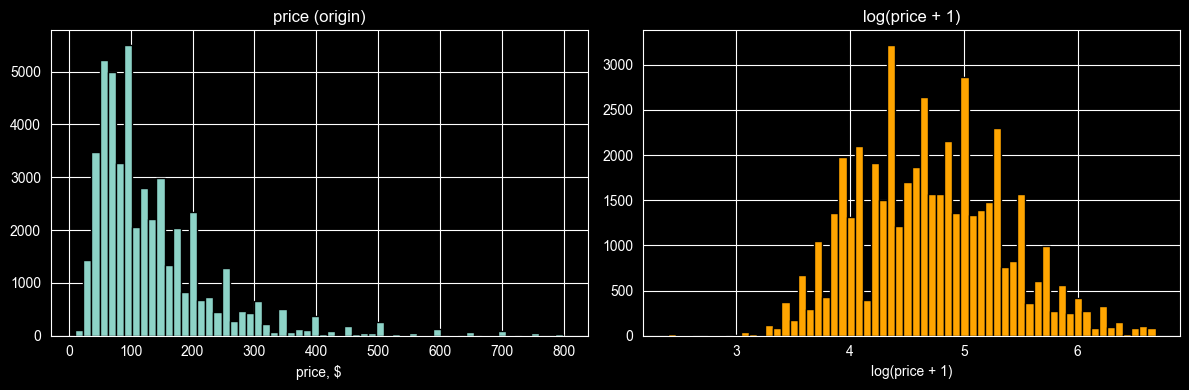

In [52]:
#Лог-преобразование целевой переменной
#Как мы уже видели на графиках Pair plot целевая переменная "price" имеет скошенное распределение — логарифм приближает его к нормальному.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(data['price'], bins=60, edgecolor='black')
axes[0].set_title('price (origin)')
axes[0].set_xlabel('price, $')

axes[1].hist(np.log1p(data['price']), bins=60, edgecolor='black', color='orange')
axes[1].set_title('log(price + 1)')
axes[1].set_xlabel('log(price + 1)')

plt.tight_layout()
plt.show()

#Используем log1p (= log(x+1)), чтобы корректно обработать нулевые значения
data['log_price'] = np.log1p(data['price'])

#Удаляем исходный столбец price, чтобы он не попал в признаки модели
data = data.drop(columns=['price'])

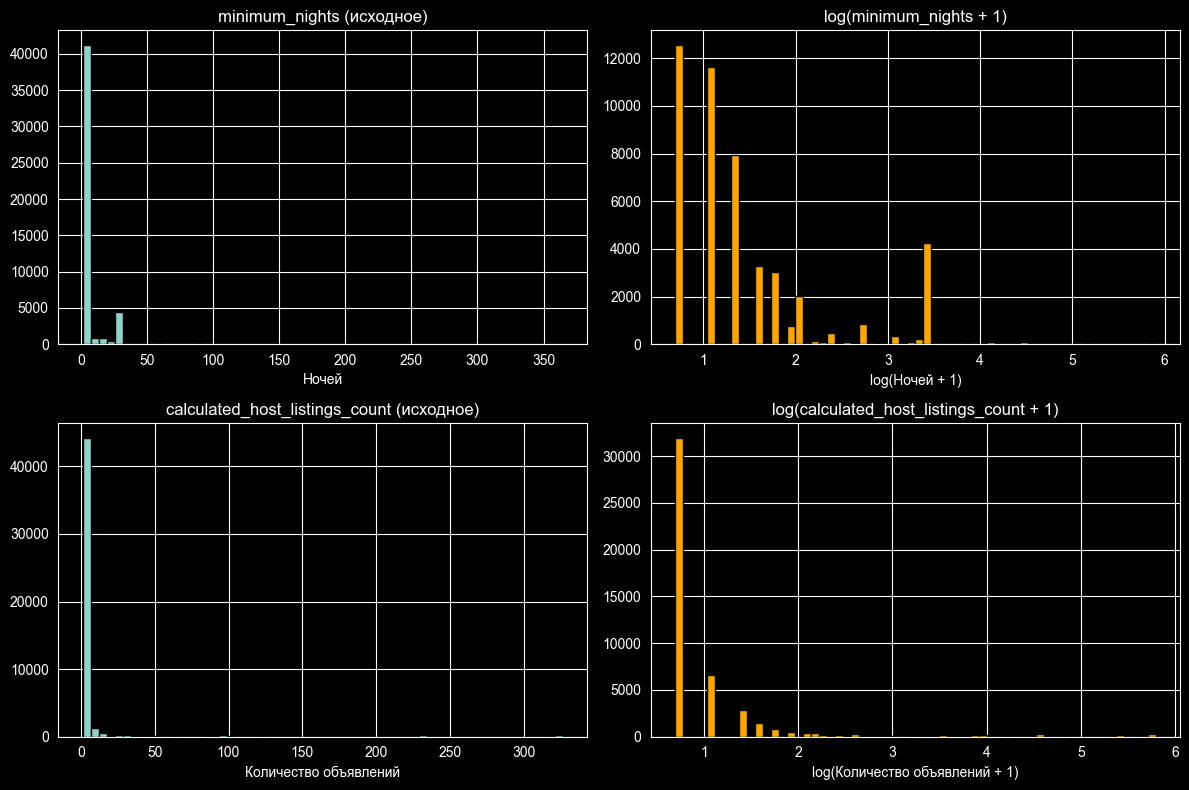

In [46]:
#Лог-преобразование другиз числовых числовых признаков
#minimum_nights и calculated_host_listings_count также имеют скошенное распределение
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(data['minimum_nights'], bins=60, edgecolor='black')
axes[0, 0].set_title('minimum_nights (исходное)')
axes[0, 0].set_xlabel('Ночей')

axes[0, 1].hist(np.log1p(data['minimum_nights']), bins=60, edgecolor='black', color='orange')
axes[0, 1].set_title('log(minimum_nights + 1)')
axes[0, 1].set_xlabel('log(Ночей + 1)')

axes[1, 0].hist(data['calculated_host_listings_count'], bins=60, edgecolor='black')
axes[1, 0].set_title('calculated_host_listings_count (исходное)')
axes[1, 0].set_xlabel('Количество объявлений')

axes[1, 1].hist(np.log1p(data['calculated_host_listings_count']), bins=60, edgecolor='black', color='orange')
axes[1, 1].set_title('log(calculated_host_listings_count + 1)')
axes[1, 1].set_xlabel('log(Количество объявлений + 1)')

plt.tight_layout()
plt.show()

#Используем log1p (= log(x+1)), чтобы корректно обработать нулевые значения
data['minimum_nights'] = np.log1p(data['minimum_nights'])
data['calculated_host_listings_count'] = np.log1p(data['calculated_host_listings_count'])


In [47]:
#После логарифмирования распределения minimum_nights и calculated_host_listings_count остаются скошенными, признаки дискретные и разреженные.
#Логарифм не помогает. Удаляем оба признака.
data = data.drop(columns=['minimum_nights', 'calculated_host_listings_count'])
print('Размерность после удаления признаков:', data.shape)

Размерность после удаления признаков: (48396, 7)


In [51]:
print(data.dtypes)

neighbourhood_group     object
neighbourhood           object
latitude               float64
longitude              float64
room_type               object
price                    int64
log_price              float64
dtype: object


In [56]:
#Посмотрим на категориальные признаки
#Смотрим на количество уникальных значений категориальных признаков
print('Уникальных значений neighbourhood_group:', data['neighbourhood_group'].nunique())
print('Уникальных значений neighbourhood:      ', data['neighbourhood'].nunique())
print('Уникальных значений room_type:           ', data['room_type'].nunique())



Уникальных значений neighbourhood_group: 5
Уникальных значений neighbourhood:       220
Уникальных значений room_type:            3


In [57]:
#One Hot Encoding (OHE) для neighbourhood_group (5 значений) и room_type
#neighbourhood имеет 200 уникальных значений, много, удалять не хочется. оставим его для target encoding (по средней цене в этом районе) после разделения данных.
data_model = pd.get_dummies(data, columns=['neighbourhood_group', 'room_type'], drop_first=True)

print('Размерность после OHE:', data_model.shape)
print('Признаки:', list(data_model.columns))

Размерность после OHE: (48396, 10)
Признаки: ['neighbourhood', 'latitude', 'longitude', 'log_price', 'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island', 'room_type_Private room', 'room_type_Shared room']


In [58]:
#Переименовываем столбцы: заменяем пробелы на подчёркивания
new_columns = {}
for column in data_model.columns:
    new_columns[column] = column.replace(' ', '_')
data_model = data_model.rename(columns=new_columns)

print('Признаки:', list(data_model.columns))

Признаки: ['neighbourhood', 'latitude', 'longitude', 'log_price', 'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten_Island', 'room_type_Private_room', 'room_type_Shared_room']


In [59]:
#Создаём новый признак: евклидово расстояние до центра Манхэттена
#Центр Манхэттена вычисляем как среднее координат объявлений из Manhattan
manhattan_data = data[data['neighbourhood_group'] == 'Manhattan']
manhattan_latitude = manhattan_data['latitude'].mean()
manhattan_longitude = manhattan_data['longitude'].mean()

print('Центр Манхэттена (среднее по объявлениям):')
print(f'  latitude:  {manhattan_latitude:.5f}')
print(f'  longitude: {manhattan_longitude:.5f}')

data['dist_to_manhattan'] = np.sqrt(
    (data['latitude'] - manhattan_latitude) ** 2 +
    (data['longitude'] - manhattan_longitude) ** 2
)

print()
print('Корреляция dist_to_manhattan с log_price:', round(data['dist_to_manhattan'].corr(data['log_price']), 3))
print('Корреляция latitude с log_price:          ', round(data['latitude'].corr(data['log_price']), 3))
print('Корреляция longitude с log_price:         ', round(data['longitude'].corr(data['log_price']), 3))

Центр Манхэттена (среднее по объявлениям):
  latitude:  40.76530
  longitude: -73.97442

Корреляция dist_to_manhattan с log_price: -0.369
Корреляция latitude с log_price:           0.082
Корреляция longitude с log_price:          -0.331
